# Practice 2 - Workflow and Agent Design Patterns

흔히 사용되는 디자인 패턴들을 살펴보겠습니다.<br>
이러한 패턴들은 AI 애플리케이션 구축을 위한 청사진 또는 재사용 가능한 템플릿이라고 생각하면 됩니다.<br>
패턴을 이해하면 확장 가능하고 모듈화 가능한 시스템을 설계할 수 있고, 이후 복잡하고 유연한 시스템을 설계할 수 있게 됩니다.

---
## Workflow vs Agent: 핵심 개념

LLM 기반 시스템을 설계할 때 중요한 결정 중 하나는 **Workflow**와 **Agent** 중 어떤 접근법을 사용할지 선택하는 것입니다.

### Workflow란?

**Workflow**는 **미리 정의된 실행 경로**를 따르는 시스템입니다.

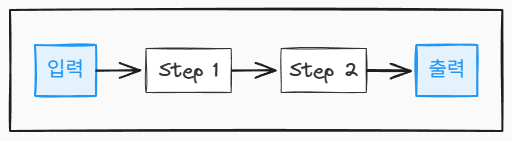

**특징:**
- 각 단계가 **사전에 정의**됨
- 실행 순서가 **고정**됨
- **예측 가능**하고 **디버깅이 쉬움**
- 작은 단계로 분해 가능한 **검증 가능한 작업**에 적합

### Agent란?

**Agent**는 **자율적으로 프로세스와 도구 사용을 결정**하는 동적 시스템입니다.
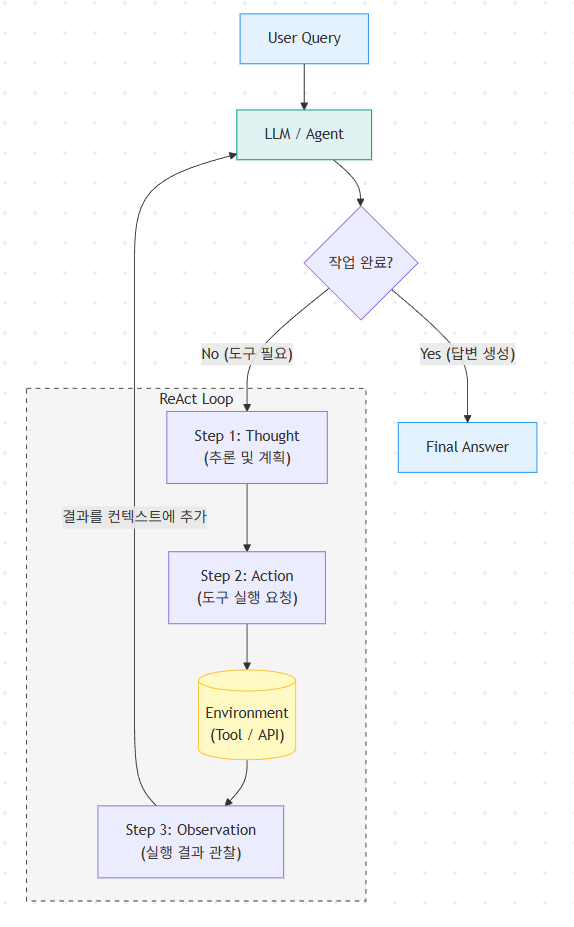


**특징:**
- **자율적으로** 어떤 도구를 사용할지 결정
- **지속적인 피드백 루프**로 동작
- 문제 해결 방식이나 단계의 선택을 **모델의 자율성에 맡기고 싶을 때 사용**
- 더 **유연**하지만 **디버깅이 어려움**

### 핵심 차이점 비교

| 특성 | Workflow | Agent |
|------|----------|-------|
| **실행 흐름** | 고정, 예측 가능 | 동적, 적응적 |
| **의사결정** | 사전에 정의됨 | 실행 중 자율 결정 |
| **도구 사용** | 미리 정해진 순서 | 상황에 따라 선택 |
| **복잡도** | 낮음~중간 | 중간~높음 |
| **디버깅** | 쉬움 (흐름 추적 가능) | 어려움 (비결정적) |
| **비용** | 예측 가능 | 변동 가능 |
| **적합한 경우** | 명확한 단계가 있는 작업 | 불확실성이 높은 작업 |

### 패턴 전체 지도

| 유형 | 패턴 | 설명 |
|------|------|------|
| **Workflow** | Prompt Chaining | 순차적 LLM 호출 |
| **Workflow** | Routing | 입력 분류 후 전문 처리 |
| **Workflow** | Parallelization | 독립 작업 병렬 실행 |
| **Workflow** | Orchestrator-Worker | 작업 분해 후 Worker 위임 |
| **Agentic** | ReAct | 추론-행동 반복 (Reasoning + Acting) |
| **Agentic** | Evaluator-Optimizer | 생성-평가 반복 개선 |
| **Agentic** | Tool Use | 외부 도구 자율 활용 |
| **Agentic** | Planning | 계획 수립 후 실행 |

---
## 환경 설정

- 실습 환경 구축을 위한 패키지 설치 (설치 후 세션을 다시 시작해야합니다.)

In [4]:
!pip install langgraph langchain-upstage langchain==1.1.3 rich

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.1/329.1 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 65.6 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.4
    Uninstalling langchain-1.2.4:
      Successfully uninstalled langchain-1.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.57.6 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.20.3 which is incompatible.


- Google Colab의 '보안 비밀번호(Secrets)' 메뉴에 등록한 API KEY를 환경 변수로 불러옵니다.

In [5]:
import os
from google.colab import userdata

# 설정할 키 목록
keys = [
    'LANGSMITH_API_KEY', 'UPSTAGE_API_KEY'
]

for key in keys:
    try:
        os.environ[key] = userdata.get(key)
    except:
        print(f"경고: {key}를 '보안 비밀번호'에서 찾을 수 없습니다.")

# 고정값 설정
os.environ["LANGSMITH_TRACING_V2"] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = 'agentic-workflow'

- 실습에 필요한 라이브러리 로드 및 LLM 모델 초기화

In [6]:
import operator
from typing import Annotated, List, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_upstage import ChatUpstage
from langchain_core.messages import SystemMessage, HumanMessage

from IPython.display import Image, display

MODEL = "solar-pro2"
llm = ChatUpstage(model=MODEL)

print("✅ 환경 설정 완료!")
print(f"   - Model: {MODEL}")

✅ 환경 설정 완료!
   - Model: solar-pro2


---
## Part 1: Workflow 패턴

Workflow 패턴은 **예측 가능하고 고정된 실행 흐름**을 가집니다.

### 1. Prompt Chaining (프롬프트 체이닝)

#### 개념
순차적 LLM 호출로, 각 출력이 다음 입력으로 전달됩니다.

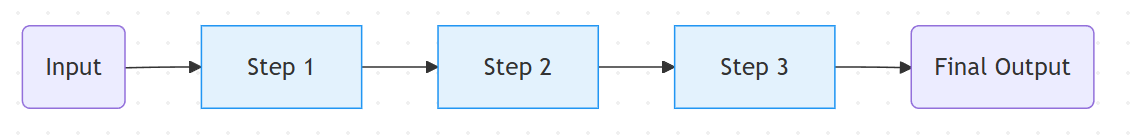

#### 특징
- 작업을 **고정된 예측 가능한 단계**로 분해
- 각 단계가 이전 단계의 출력을 처리
- **깔끔하게 분리 가능한 하위 작업**에 적합

#### 사용 사례
- 구조화된 문서 생성 (개요 → 검증 → 내용 작성)
- 다단계 데이터 처리 (추출 → 변환 → 요약)
- 뉴스레터 생성

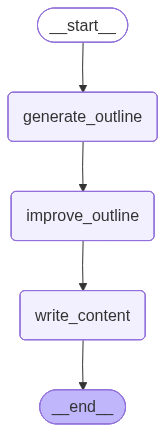

✅ Prompt Chaining Graph 생성 완료!


In [7]:
# ========================================
# Prompt Chaining with LangGraph
# ========================================

# Step 1: State 정의 - 노드 간 공유할 데이터
class ChainState(TypedDict):
    topic: str           # 입력 주제
    outline: str         # 1단계: 개요
    improved: str        # 2단계: 개선된 개요
    content: str         # 3단계: 최종 콘텐츠

# Step 2: Node 함수들 정의
def generate_outline(state: ChainState) -> dict:
    """1단계: 개요 생성"""
    print("📝 Step 1: 개요 생성 중...")
    msg = llm.invoke(f"'{state['topic']}'에 대한 블로그 포스트 개요를 3-4개 섹션으로 작성하세요.")
    return {"outline": msg.content}

def improve_outline(state: ChainState) -> dict:
    """2단계: 개요 검증 및 개선"""
    print("🔍 Step 2: 개요 검증 및 개선 중...")
    msg = llm.invoke(f"다음 개요를 검토하고 개선하세요:\n\n{state['outline']}")
    return {"improved": msg.content}

def write_content(state: ChainState) -> dict:
    """3단계: 최종 콘텐츠 작성"""
    print("✍️ Step 3: 콘텐츠 작성 중...")
    msg = llm.invoke(f"다음 개요를 바탕으로 블로그 포스트를 작성하세요:\n\n{state['improved']}")
    return {"content": msg.content}

# Step 3: Graph 구성
chain_builder = StateGraph(ChainState)

# 노드 추가
chain_builder.add_node("generate_outline", generate_outline)
chain_builder.add_node("improve_outline", improve_outline)
chain_builder.add_node("write_content", write_content)

# 엣지 연결 (순차적)
chain_builder.add_edge(START, "generate_outline")
chain_builder.add_edge("generate_outline", "improve_outline")
chain_builder.add_edge("improve_outline", "write_content")
chain_builder.add_edge("write_content", END)

# 컴파일
chain_workflow = chain_builder.compile()

display(Image(chain_workflow.get_graph().draw_mermaid_png()))
print("✅ Prompt Chaining Graph 생성 완료!")

In [8]:
# Prompt Chaining 실행 예시
result = chain_workflow.invoke({"topic": "AI Agent의 미래"})
print(result["content"])

📝 Step 1: 개요 생성 중...
🔍 Step 2: 개요 검증 및 개선 중...
✍️ Step 3: 콘텐츠 작성 중...
# **AI Agent의 미래: 인간과 기계가 공존하는 새로운 시대**

## **1. 서론: AI Agent가 가져올 패러다임의 전환**  
"2030년, 아침 7시. 당신의 AI 비서가 커피를 내려주며 오늘의 일정을 브리핑합니다. 출근길에는 자율주행 차량이 교통 상황을 예측해 최적의 경로를 안내하고, 회사에서는 AI 동료가 데이터를 분석해 핵심 인사이트를 제시합니다. 병원 예약부터 세금 신고까지, 모든 것이 AI Agent와 협업해 처리됩니다."  

이런 미래가 이제 더 이상 공상과학 소설이 아닙니다. AI Agent는 단순한 도구를 넘어 **자율적 행위자(Autonomous Agent)**로 진화하며 인간의 삶을 재정의하고 있습니다. 이 글에서는 AI Agent의 기술적 발전부터 산업 변화, 일상의 적용, 그리고 공존 전략까지 체계적으로 탐구합니다. 기술과 인간성의 균형을 고민하며, **"어떤 미래를 설계할지"** 함께 고민해보는 시간이 되기를 바랍니다.

---

## **2. AI Agent의 진화: 기술에서 인간성으로**  
### **기술적 기반: 통합 지능의 탄생**  
- **생성형 AI + 강화학습 + 멀티모달 처리**  
  GPT-4o는 텍스트와 음성을 자유롭게 변환하며, DeepMind의 AlphaSeries는 복잡한 문제를 스스로 학습합니다. RT-2 로봇은 시각 데이터를 분석해 물리적 세계와 상호작용합니다.  
- **Embodied AI의 실현 조건**  
  물리적 세계 인식을 위한 로봇틱스, 실시간 의사결정을 위한 에지 컴퓨팅(Edge Computing)이 결합되며, AI는 이제 **행동하는 지능**으로 진화 중입니다.  

### **인간적 요소: 감정을 이해하는 AI**  
- Replika는 사용자의 감정을 분석해 대화를 조정하며, ChatGPT는 맥락 기반 추론으로 인간과 유사한 응답을 생성합니다

---
### 2. Routing (라우팅)

#### 개념
초기 LLM 분류기가 입력을 전문화된 다운스트림 핸들러로 라우팅합니다.

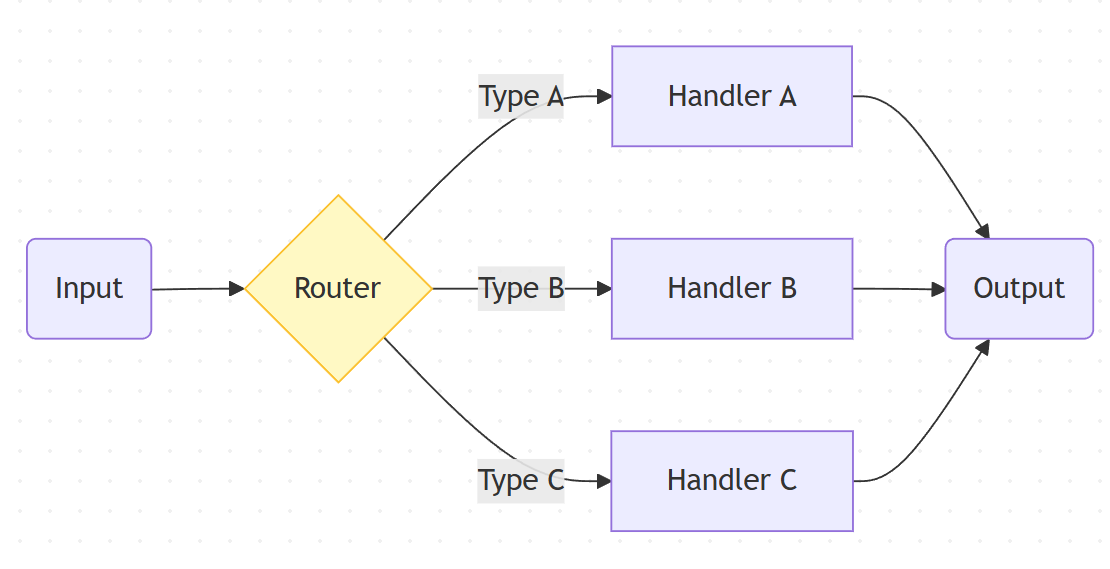


#### 특징
- **관심사 분리** 구현
- 입력 분류 기반 라우팅
- 개별 작업 핸들러를 **독립적으로 최적화** 가능
- 작업 복잡도에 맞는 모델 매칭으로 **비용 절감**

#### 사용 사례
- 고객 지원 (청구 문의 → 청구 에이전트, 기술 문의 → 기술 지원팀)
- 계층형 모델 사용 (간단한 쿼리 → 저렴한 모델, 복잡한 쿼리 → 고급 모델)
- 콘텐츠별 라우팅 (블로그 요청, 소셜 미디어, 광고 카피)

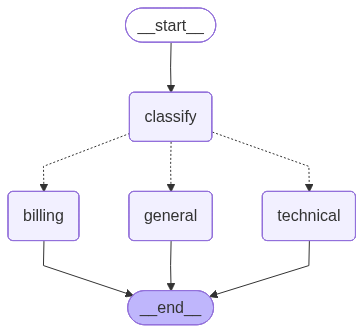

✅ Routing Graph 생성 완료!


In [ ]:
# ========================================
# Routing Pattern with LangGraph
# ========================================

# Structured Output을 위한 Pydantic 모델
class RouteDecision(BaseModel):
    """라우팅 결정"""
    category: Literal["billing", "technical", "general"] = Field(
        description="문의 카테고리: billing(결제), technical(기술), general(일반)"
    )
    confidence: float = Field(description="신뢰도 0.0-1.0")

# State 정의
class RouterState(TypedDict):
    query: str              # 고객 문의
    category: str           # 분류 결과
    confidence: float       # 신뢰도
    response: str           # 응답

# 구조화된 출력을 위한 LLM
router_llm = llm.with_structured_output(RouteDecision)

# Node 함수들
def classify_query(state: RouterState) -> dict:
    """문의 분류"""
    print(f"🔍 문의 분류 중: {state['query'][:30]}...")
    result = router_llm.invoke(
        f"다음 고객 문의를 분류하세요: {state['query']}"
    )
    print(f"   → 분류: {result.category} (신뢰도: {result.confidence:.0%})")
    return {"category": result.category, "confidence": result.confidence}

def billing_handler(state: RouterState) -> dict:
    """결제 문의 처리"""
    print("💳 결제 전문 상담원 응답 중...")
    msg = llm.invoke([
        SystemMessage(content="당신은 결제/청구 전문 상담원입니다. 친절하고 정확하게 답변하세요."),
        HumanMessage(content=state["query"])
    ])
    return {"response": msg.content}

def technical_handler(state: RouterState) -> dict:
    """기술 문의 처리"""
    print("🔧 기술 지원 전문가 응답 중...")
    msg = llm.invoke([
        SystemMessage(content="당신은 기술 지원 전문가입니다. 문제 해결에 집중하여 답변하세요."),
        HumanMessage(content=state["query"])
    ])
    return {"response": msg.content}

def general_handler(state: RouterState) -> dict:
    """일반 문의 처리"""
    print("👋 고객 서비스 담당자 응답 중...")
    msg = llm.invoke([
        SystemMessage(content="당신은 친절한 고객 서비스 담당자입니다."),
        HumanMessage(content=state["query"])
    ])
    return {"response": msg.content}

# 라우팅 조건 함수
def route_by_category(state: RouterState) -> str:
    """카테고리에 따라 적절한 핸들러로 라우팅"""
    return state["category"]

# Graph 구성
router_builder = StateGraph(RouterState)

# 노드 추가
router_builder.add_node("classify", classify_query)
router_builder.add_node("billing", billing_handler)
router_builder.add_node("technical", technical_handler)
router_builder.add_node("general", general_handler)

# 엣지 연결
router_builder.add_edge(START, "classify")

# 조건부 엣지: 분류 결과에 따라 다른 핸들러로
router_builder.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "billing": "billing",
        "technical": "technical",
        "general": "general"
    }
)

# 모든 핸들러는 END로
router_builder.add_edge("billing", END)
router_builder.add_edge("technical", END)
router_builder.add_edge("general", END)

# 컴파일
router_workflow = router_builder.compile()

display(Image(router_workflow.get_graph().draw_mermaid_png()))
print("✅ Routing Graph 생성 완료!")

In [ ]:
# Routing 실행 예시
result = router_workflow.invoke({"query": "이번 달 청구서가 왜 이렇게 높은가요?"})
print(result["response"])

🔍 문의 분류 중: 이번 달 청구서가 왜 이렇게 높은가요?...
   → 분류: billing (신뢰도: 95%)
💳 결제 전문 상담원 응답 중...
이번 달 청구서 금액이 평소보다 높게 나와 당황스러우셨을 것 같습니다. 고객의 사용 내역을 확인해 드리기 위해 몇 가지 확인이 필요합니다. 아래 사항 중 해당하시는 부분을 알려주시면 자세히 안내드리겠습니다.

1. **사용량 확인**: 이번 달 사용량이 평소보다 크게 증가했는지 확인이 필요합니다. (예: 전기/가스/수도 사용량, 데이터 사용량 등)
2. **요금제 변경**: 최근에 요금제 또는 서비스 플랜이 변경되었는지 확인해 주세요.
3. **추가 서비스**: 부가 서비스(해외 로밍, 프리미엄 채널 등)를 새로 이용하셨는지 확인해 보겠습니다.
4. **일시적인 요금**: 계절별 요금(냉방/난방 수요 증가), 프로모션 종료 후 정산 등이 반영되었을 수 있습니다.
5. **할인 혜택 종료**: 기존 할인 혜택(통신사/카드사 제휴 할인 등)이 이번 달부터 적용되지 않았을 가능성도 있습니다.

📌 **추가 안내**  
- 청구서 상세 내역(영수증 또는 앱 내 내역)을 함께 확인하시면 더 정확한 이유를 파악할 수 있습니다.  
- 고객센터(☎XXX-XXXX-XXXX) 또는 [온라인 문의](링크)를 통해 청구서 번호와 함께 문의해 주시면 즉시 조회 후 안내드리겠습니다.

고객의 불편을 최소화하기 위해 최선을 다하겠습니다. 감사합니다! 😊


---
### 3. Parallelization (병렬화)

#### 개념
작업을 독립적인 하위 작업으로 분해하여 동시에 실행한 후 결과를 집계합니다.

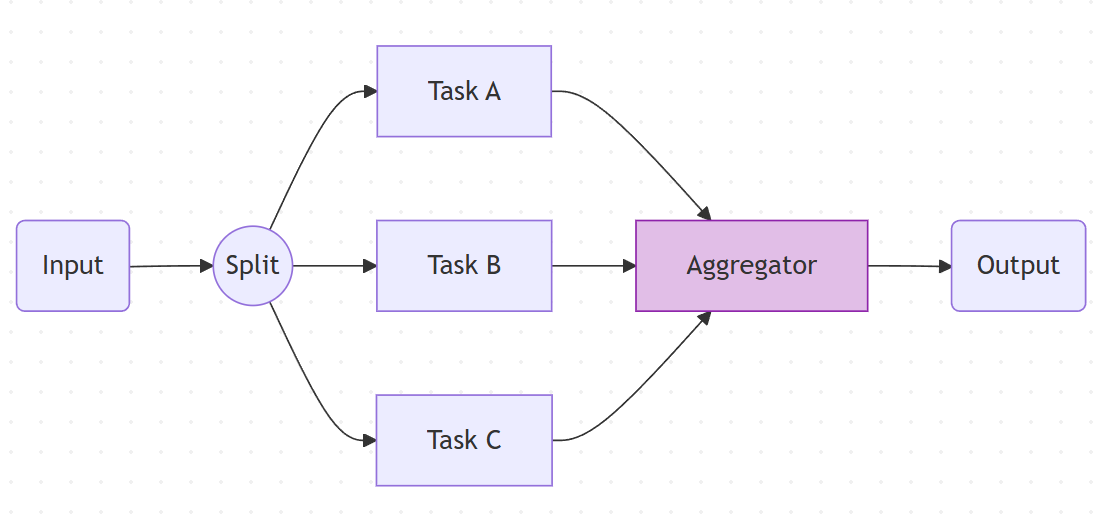

#### 특징
- **지연 시간 개선** (독립적 작업의 동시 실행)
- **품질 향상** (다양한 관점 통합)
- 동시 처리 사용
- 최종 집계 LLM이 출력 종합

#### 사용 사례
- RAG 시스템의 쿼리 분해
- 병렬 문서 섹션 요약
- 다중 관점 응답 생성
- Map-Reduce 스타일 작업

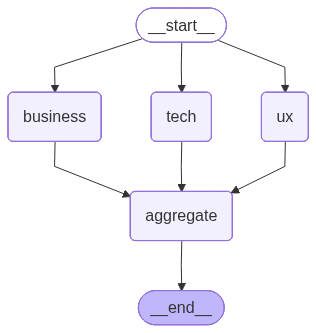

✅ Parallelization Graph 생성 완료!


In [ ]:
# ========================================
# Parallelization Pattern with LangGraph
# ========================================

# State 정의
class ParallelState(TypedDict):
    topic: str                # 입력 주제
    tech_analysis: str        # 기술적 분석
    business_analysis: str    # 비즈니스 분석
    ux_analysis: str          # UX 분석
    combined: str             # 종합 결과

# Node 함수들 (병렬 실행될 분석들)
def analyze_tech(state: ParallelState) -> dict:
    """기술적 관점 분석"""
    print("🔬 기술적 분석 중...")
    msg = llm.invoke(f"'{state['topic']}'을(를) 기술적 관점에서 분석하세요. (2-3문장)")
    return {"tech_analysis": msg.content}

def analyze_business(state: ParallelState) -> dict:
    """비즈니스 관점 분석"""
    print("💼 비즈니스 분석 중...")
    msg = llm.invoke(f"'{state['topic']}'을(를) 비즈니스 관점에서 분석하세요. (2-3문장)")
    return {"business_analysis": msg.content}

def analyze_ux(state: ParallelState) -> dict:
    """UX 관점 분석"""
    print("🎨 UX 분석 중...")
    msg = llm.invoke(f"'{state['topic']}'을(를) 사용자 경험 관점에서 분석하세요. (2-3문장)")
    return {"ux_analysis": msg.content}

def aggregate_analyses(state: ParallelState) -> dict:
    """모든 분석 결과 종합"""
    print("📊 분석 결과 종합 중...")
    combined_input = f"""다음 분석들을 종합하여 핵심 인사이트를 제시하세요:

- 기술적 분석: {state['tech_analysis']}
- 비즈니스 분석: {state['business_analysis']}
- UX 분석: {state['ux_analysis']}"""

    msg = llm.invoke(combined_input)
    return {"combined": msg.content}

# Graph 구성
parallel_builder = StateGraph(ParallelState)

# 노드 추가
parallel_builder.add_node("tech", analyze_tech)
parallel_builder.add_node("business", analyze_business)
parallel_builder.add_node("ux", analyze_ux)
parallel_builder.add_node("aggregate", aggregate_analyses)

# 병렬 엣지: START에서 3개 노드로 동시에 연결
parallel_builder.add_edge(START, "tech")
parallel_builder.add_edge(START, "business")
parallel_builder.add_edge(START, "ux")

# 모든 분석이 aggregator로 연결
parallel_builder.add_edge("tech", "aggregate")
parallel_builder.add_edge("business", "aggregate")
parallel_builder.add_edge("ux", "aggregate")

# 종합 후 종료
parallel_builder.add_edge("aggregate", END)

# 컴파일
parallel_workflow = parallel_builder.compile()


import nest_asyncio
nest_asyncio.apply() # mermaid 랜더링을 위해 중첩 이벤트 루프 허용
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))
print("✅ Parallelization Graph 생성 완료!")

In [ ]:
# Parallelization 실행 예시
result = parallel_workflow.invoke({"topic": "생성형 AI"})
print(result["combined"])

💼 비즈니스 분석 중...
🔬 기술적 분석 중...
🎨 UX 분석 중...
📊 분석 결과 종합 중...
### 핵심 인사이트 종합  
생성형 AI는 **기술적 혁신**, **비즈니스 가치 창출**, **UX 혁신**이라는 3가지 축에서 산업 전반에 걸쳐 파급력을 가지며, 다음과 같은 전략적 기회와 도전 과제를 동시에 내포합니다.  

---

#### 1. **기술적 혁신과 효율성 극대화**  
- **대규모 학습 + 파인튜닝/프롬프트 엔지니어링**의 결합으로 고도화된 생성 능력 확보 가능  
  - 예: 적은 데이터로도 특정 도메인(예: 의료, 법률)에 최적화된 맞춤형 모델 개발 가능  
- **트랜스포머 아키텍처**와 **확산 모델**의 발전은 멀티모달(텍스트·이미지·음성 통합) 생성의 정밀도를 높임  
- **도전 과제**: 컴퓨팅 자원 및 데이터 확보 비용, 모델 해석 가능성(Explainability) 부재  

---

#### 2. **비즈니스 경쟁력 재정의**  
- **개인화된 콘텐츠 제작** (예: 맞춤형 마케팅, 교육 자료) 및 **자동화된 프로세스** (예: 코드 생성, 고객 응대)로 운영 효율성 200% 이상 향상 가능  
- **신제품 개발 주기 단축**: AI가 제안한 디자인/기능 시안을 기반으로 R&D 기간 감소  
- **리스크 관리 핵심**:  
  - 초기 투자 대비 ROI 확보를 위한 **점진적 도입 전략** (예: 파일럿 테스트 → 확장)  
  - **윤리적 리스크** (편향성, 저작권)를 고려한 **감사 시스템** 구축  

---

#### 3. **UX 혁신과 사용자 신뢰 구축**  
- **긍정적 영향**:  
  - **개인화된 상호작용** (예: AI 어시스턴트의 맥락 이해) → 사용자 참여도 증가  
  - **창의성 증폭** (예: 디자인 아이디어 자동 생성)으로 문제 해결 속도 향상  
- **주요 리스크**:  
  - **정보 신뢰도 저하** (허구적 출력, Hallucination) → 사용자 혼란 

---
### 4. Orchestrator-Worker 패턴

#### 개념
**Orchestrator**가 작업을 **동적으로 분해**하고, 각 **Worker**에게 위임한 후 결과를 종합합니다.
**LangGraph**에서는 `Send`를 사용하여 **동적으로 Worker 노드를 생성**합니다.

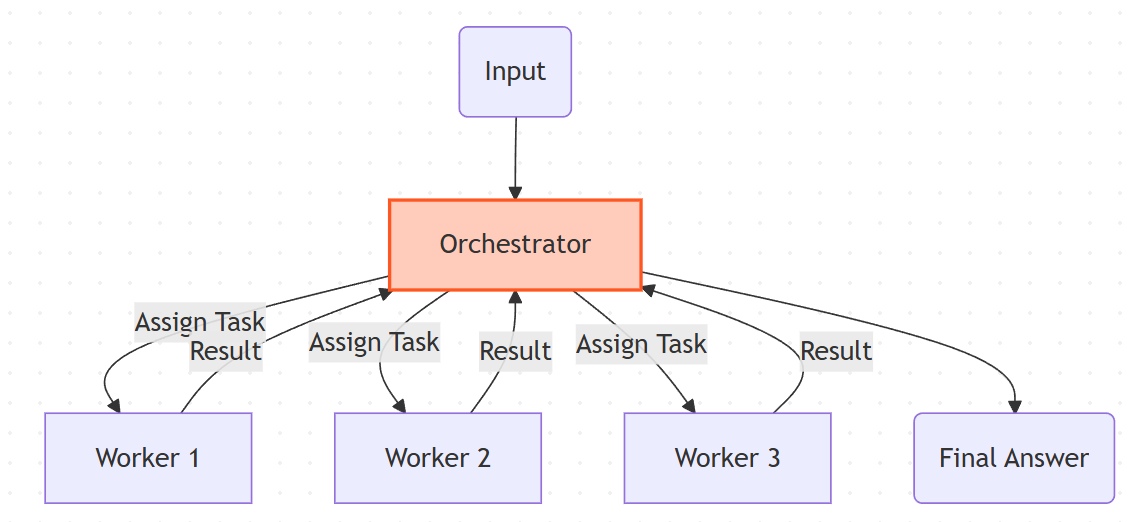

#### Prompt Chaining vs Orchestrator-Worker

| 특성 | Prompt Chaining | Orchestrator-Worker |
|------|-----------------|---------------------|
| **하위 작업** | 사전 정의됨 | **런타임에 동적 결정** |
| **Worker 수** | 고정됨 | **입력에 따라 가변** |
| **실행 방식** | 순차적 | **병렬 가능** |
| **LangGraph** | `add_edge` | `Send()` |

#### 핵심: `Send()` 함수
- **동적으로 노드 실행**을 트리거
- 각 Worker에 **개별 상태**를 전달
- Orchestrator가 결정한 수만큼 Worker 생성

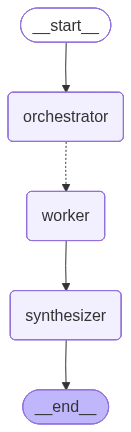

✅ Orchestrator-Worker Graph 생성 완료!


In [ ]:
# ========================================
# Orchestrator-Worker Pattern with LangGraph
# ========================================

# Orchestrator가 생성할 Section 구조
class Section(BaseModel):
    """보고서 섹션"""
    name: str = Field(description="섹션 이름")
    description: str = Field(description="섹션 설명")

class Sections(BaseModel):
    """섹션 목록"""
    sections: List[Section] = Field(description="보고서 섹션들")

# 구조화된 출력을 위한 LLM
planner_llm = llm.with_structured_output(Sections)

# Main State (전체 워크플로우)
class OrchestratorState(TypedDict):
    task: str                                           # 원래 작업
    sections: List[Section]                             # 분해된 섹션들
    completed_sections: Annotated[list, operator.add]   # 완료된 섹션들 (자동 병합)
    final_report: str                                   # 최종 보고서

# Worker State (개별 Worker용)
class WorkerState(TypedDict):
    section: Section                                    # 담당 섹션
    completed_sections: Annotated[list, operator.add]   # 결과 반환용

# Node 함수들
def orchestrator(state: OrchestratorState) -> dict:
    """작업을 동적으로 섹션들로 분해"""
    print(f"🎯 Orchestrator: 작업 분해 중...")
    print(f"   작업: {state['task']}")

    result = planner_llm.invoke([
        SystemMessage(content="주어진 작업을 수행하기 위한 보고서 섹션들을 계획하세요. 3-4개 섹션으로 나누세요."),
        HumanMessage(content=f"작업: {state['task']}")
    ])

    print(f"   → {len(result.sections)}개 섹션으로 분해:")
    for i, s in enumerate(result.sections, 1):
        print(f"      {i}. {s.name}")

    return {"sections": result.sections}

def worker(state: WorkerState) -> dict:
    """개별 섹션 작성"""
    section = state["section"]
    print(f"👷 Worker: '{section.name}' 섹션 작성 중...")

    msg = llm.invoke([
        SystemMessage(content="주어진 섹션에 대한 내용을 마크다운 형식으로 작성하세요."),
        HumanMessage(content=f"섹션: {section.name}\n설명: {section.description}")
    ])

    return {"completed_sections": [f"## {section.name}\n\n{msg.content}"]}

def synthesizer(state: OrchestratorState) -> dict:
    """모든 섹션을 최종 보고서로 종합"""
    print(f"📊 Synthesizer: {len(state['completed_sections'])}개 섹션 종합 중...")

    final_report = f"# {state['task']}\n\n"
    final_report += "\n\n---\n\n".join(state["completed_sections"])

    return {"final_report": final_report}

def assign_workers(state: OrchestratorState) -> list:
    """동적으로 Worker 생성 - Send() 사용"""
    return [Send("worker", {"section": section}) for section in state["sections"]]

# Graph 구성
ow_builder = StateGraph(OrchestratorState)

# 노드 추가
ow_builder.add_node("orchestrator", orchestrator)
ow_builder.add_node("worker", worker)
ow_builder.add_node("synthesizer", synthesizer)

# 엣지 연결
ow_builder.add_edge(START, "orchestrator")
ow_builder.add_conditional_edges("orchestrator", assign_workers, ["worker"])
ow_builder.add_edge("worker", "synthesizer")
ow_builder.add_edge("synthesizer", END)

# 컴파일
orchestrator_worker_workflow = ow_builder.compile()

display(Image(orchestrator_worker_workflow.get_graph().draw_mermaid_png()))
print("✅ Orchestrator-Worker Graph 생성 완료!")

In [ ]:
# Orchestrator-Worker 실행 예시
result = orchestrator_worker_workflow.invoke({"task": "AI Agent 트렌드 보고서 작성"})
print(result["final_report"])

🎯 Orchestrator: 작업 분해 중...
   작업: AI Agent 트렌드 보고서 작성
   → 4개 섹션으로 분해:
      1. 기술 트렌드 분석
      2. 산업별 적용 현황
      3. 도전 과제 및 리스크
      4. 미래 전망
👷 Worker: '기술 트렌드 분석' 섹션 작성 중...
👷 Worker: '산업별 적용 현황' 섹션 작성 중...
👷 Worker: '도전 과제 및 리스크' 섹션 작성 중...
👷 Worker: '미래 전망' 섹션 작성 중...
📊 Synthesizer: 4개 섹션 종합 중...
# AI Agent 트렌드 보고서 작성

## 기술 트렌드 분석

# 기술 트렌드 분석: AI 에이전트 기술 동향

## 1. AI 에이전트 기술의 정의 및 진화
- **AI 에이전트**란 환경 인식 → 자율적 의사결정 → 목표 달성을 위한 행동 수행 체계를 갖춘 지능형 소프트웨어/하드웨어 시스템
- 1세대(규칙 기반) → 2세대(머신러닝 통합) → 3세대(멀티모달 + 자기진화형)로 진화 중
- 2024년 기준, **자율성(Autonomy)**과 **적응성(Adaptability)**이 핵심 평가 지표로 부상

## 2. 최신 기술 동향 (2023-2024)
### (1) 멀티모달 처리 능력 강화
- GPT-4o, Gemini 1.5 등 텍스트/이미지/음성/비디오 통합 처리 모델 등장
- 예: OpenAI의 **GPT-4o** (실시간 음성 대화 + 시각적 입력 처리)

### (2) 메모리 및 컨텍스트 확장
- **Long-Context Window** 기술 발전 (최대 128K 토큰 처리)
- **메모리 네트워크(Memory Networks)** 도입으로 장기적 맥락 이해 가능

### (3) 실시간 의사결치 시스템
- 자율주행을 위한 **End-to-End AI 에이전트** (Tesla Dojo, Wayve)
- 로봇 공학의 **시뮬레이션 학습(Sim2Real)** 적용 확대

### (4) 인간-AI 협업 진화
- **

---
### 5. Tool Use Pattern (도구 사용)

#### 개념
LLM이 외부 도구를 호출하여 능력을 확장합니다.

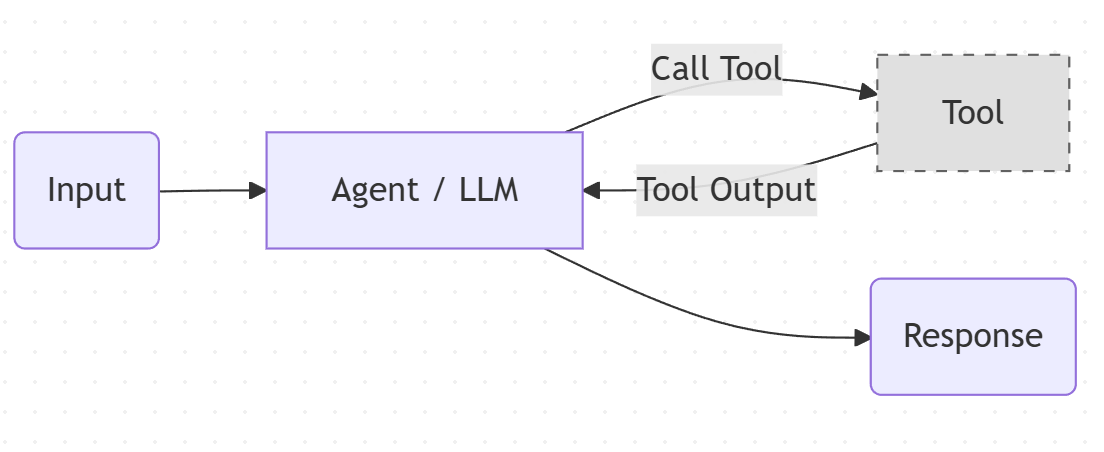


*자세한 내용은 Lecture 3에서 다룹니다.*

In [ ]:
# ========================================
# Tool Use Pattern Preview (간단 예시)
# ========================================
# 전체 구현은 Lecture 3에서 다룹니다.

from langchain.tools import tool

# Tool 정의
@tool
def calculator(expression: str) -> str:
    """수학 계산을 수행합니다. 예: '2 + 2', '10 * 5'"""
    try:
        result = eval(expression)
        return f"계산 결과: {expression} = {result}"
    except:
        return "계산할 수 없는 수식입니다."

@tool
def get_weather(city: str) -> str:
    """도시의 날씨를 조회합니다."""
    weather_data = {"서울": "맑음, 15°C", "부산": "흐림, 18°C"}
    return weather_data.get(city, f"{city}의 날씨 정보가 없습니다.")

# LLM에 Tool 바인딩
tools = [calculator, get_weather]
llm_with_tools = llm.bind_tools(tools)

# 테스트
response = llm_with_tools.invoke("123 * 456을 계산해주세요")

if response.tool_calls:
    print("🔧 Tool 호출 감지:")
    for tc in response.tool_calls:
        print(f"   - Tool: {tc['name']}")
        print(f"   - Args: {tc['args']}")
else:
    print("💬 일반 응답:", response.content)

---
## Part 2: Agentic 패턴

Agentic 패턴은 **동적이고 자율적인 의사결정**을 특징으로 합니다.

### 6. ReAct 패턴 (Reasoning + Acting)

#### 개념
LLM이 추론(Reasoning)과 행동(Acting)을 반복하며 문제를 해결합니다.
각 단계에서 "생각 → 행동 → 관찰"의 루프를 돌며 최종 답에 도달합니다.

#### 상호작용 시퀀스

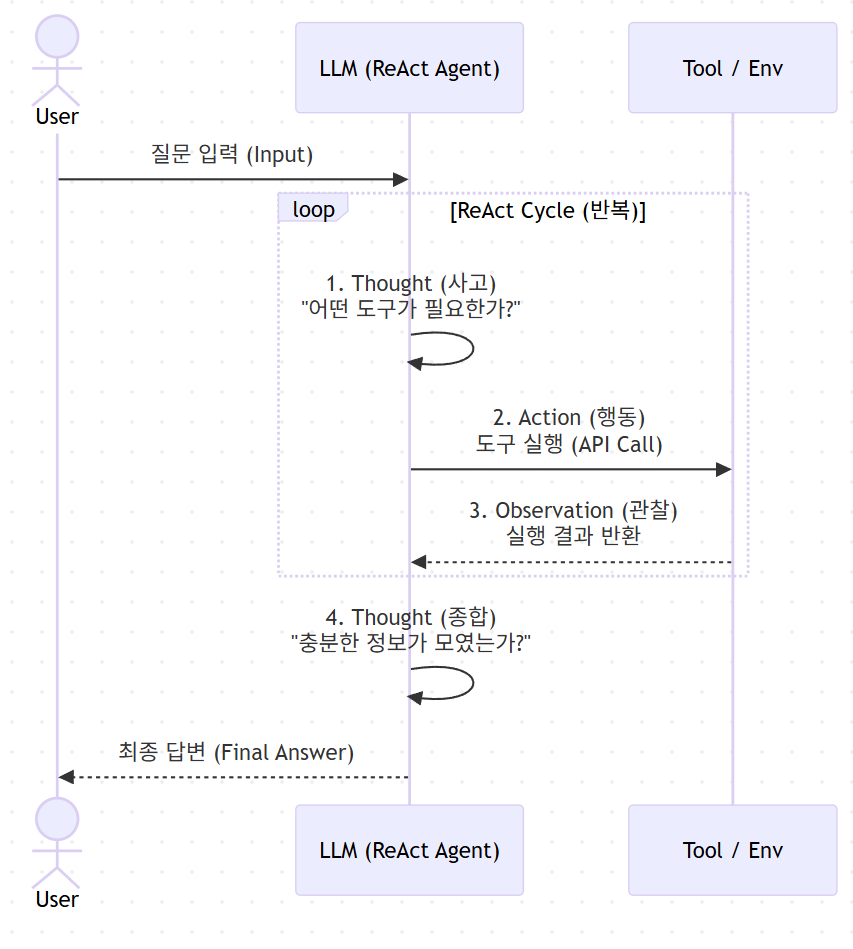

#### 특징
- **Thought**: 현재 상황을 분석하고 다음 행동을 계획
- **Action**: 외부 도구를 호출하여 정보 수집 또는 작업 수행
- **Observation**: 도구 실행 결과를 확인
- **반복**: 충분한 정보가 모일 때까지 루프 반복
- **자율성**: LLM이 스스로 언제 멈출지 결정

#### 사용 사례
- 검색 기반 질의응답 (Search + QA)
- 계산이 필요한 문제 해결 (Calculator)
- API 호출이 필요한 작업 (날씨, 주가 조회)
- 다단계 정보 수집 및 종합

#### Workflow vs ReAct 비교

| 특성 | Workflow (Prompt Chaining) | ReAct (Agent) |
|------|---------------------------|---------------|
| **실행 흐름** | 고정된 순서 | 동적, LLM이 결정 |
| **도구 사용** | 사전 정의됨 | 상황에 따라 선택 |
| **종료 조건** | 마지막 단계 완료 | LLM이 "충분하다" 판단 |
| **예측 가능성** | 높음 | 낮음 |
| **디버깅** | 쉬움 | 어려움 |

In [ ]:
# ========================================
# ReAct Preview (간단 예시)
# ========================================

# pre-built
from langchain.agents import create_agent

react_agent = create_agent(llm, tools=tools)

display(Image(react_agent.get_graph().draw_mermaid_png()))

print("✅ react-agent Graph 생성 완료!")

In [ ]:
# ReAct Agent 실행 예시
result = react_agent.invoke({"messages": [{"role": "user", "content": "15 + 27 결과와 '서울 날씨' 검색해줘"}]})
print(result['messages'][-1].content)

---
### 7. Evaluator-Optimizer 패턴 (평가자-최적화)

#### 개념
**생성 → 평가 → 개선**을 반복하여 품질을 높이는 패턴입니다.

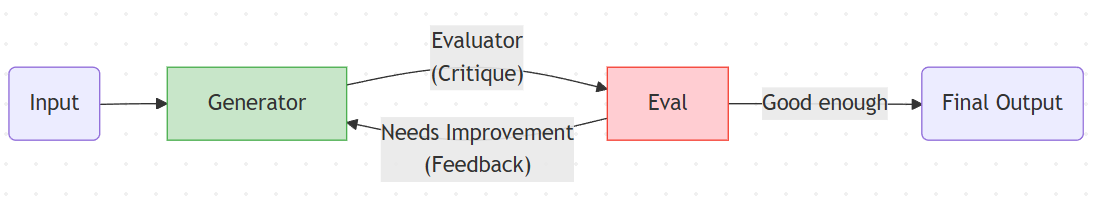


#### 특징
- **Optimizer**: 콘텐츠 생성 또는 피드백 기반 개선
- **Evaluator**: 품질 평가 및 피드백 제공
- **루프**: 품질 기준 충족까지 반복
- **자기 개선**: LLM이 자신의 출력을 평가하고 개선

#### 사용 사례
- 콘텐츠 작성 (글 → 리뷰 → 수정 반복)
- 코드 생성 (코드 → 테스트 → 디버깅 반복)
- 번역 (번역 → 품질 평가 → 재번역 반복)

In [ ]:
# ========================================
# Evaluator-Optimizer Pattern with LangGraph
# ========================================

# 평가 결과를 위한 Pydantic 모델
class Evaluation(BaseModel):
    """평가 결과"""
    score: int = Field(description="점수 1-10")
    passed: bool = Field(description="통과 여부 (9점 이상)")
    feedback: str = Field(description="개선을 위한 피드백")

# 구조화된 출력을 위한 LLM
evaluator_llm = llm.with_structured_output(Evaluation)

# State 정의
class EvalOptState(TypedDict):
    task: str           # 원래 작업
    content: str        # 생성된 콘텐츠
    feedback: str       # 평가 피드백
    score: int          # 평가 점수
    passed: bool        # 통과 여부
    iteration: int      # 반복 횟수

# Node 함수들
def optimizer(state: EvalOptState) -> dict:
    """콘텐츠 생성/개선"""
    iteration = state.get("iteration", 0) + 1
    print(f"\n🔧 Optimizer (반복 {iteration}): ", end="")

    if state.get("feedback"):
        print("피드백 반영하여 개선 중...")
        prompt = f"""작업: {state['task']}

이전 피드백을 반영하여 개선하세요: {state['feedback']}

이전 콘텐츠:
{state['content']}"""
    else:
        print("초기 생성 중...")
        prompt = f"작업: {state['task']}"

    msg = llm.invoke(prompt)
    return {"content": msg.content, "iteration": iteration}

def evaluator(state: EvalOptState) -> dict:
    """콘텐츠 평가"""
    print(f"📊 Evaluator: 평가 중...")

    result = evaluator_llm.invoke(
        f"다음 결과물을 1-10점으로 평가하세요. 9점 이어야 통과입니다.\n\n결과물: {state['content']}"
    )

    print(f"   → 점수: {result.score}점 ({'통과' if result.passed else '재시도 필요'})")
    if not result.passed:
        print(f"   → 피드백: {result.feedback[:50]}...")

    return {
        "score": result.score,
        "passed": result.passed,
        "feedback": result.feedback
    }

def should_continue(state: EvalOptState) -> str:
    """평가 결과에 따라 계속 여부 결정"""

    if state.get("iteration", 0) >= 3:
        print("⚠️ 최대 반복 횟수 도달")
        return "pass"

    if state.get("passed", False):
        print("✅ 품질 기준 통과!")
        return "pass"
    else:
        print("🔄 재시도...")
        return "fail"

# Graph 구성
eo_builder = StateGraph(EvalOptState)

# 노드 추가
eo_builder.add_node("optimizer", optimizer)
eo_builder.add_node("evaluator", evaluator)

# 엣지 연결
eo_builder.add_edge(START, "optimizer")
eo_builder.add_edge("optimizer", "evaluator")

# 조건부 엣지: 평가 결과에 따라 루프 또는 종료
eo_builder.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "pass": END,
        "fail": "optimizer"
    }
)

# 컴파일
evaluator_optimizer_workflow = eo_builder.compile()

print("✅ Evaluator-Optimizer Graph 생성 완료!")

In [ ]:
# Evaluator-Optimizer 실행
result = evaluator_optimizer_workflow.invoke({
    "task": "양자역학에 대해 5세 아이도 이해할 수 있게 설명하되,\
     딱 3문장으로 작성하고, 각 문장은 반드시 이모지로 끝나야 하며,\
    '컴퓨터'라는 단어를 절대 사용하지 마세요."
})

print("\n" + "="*60)
print(f"📝 최종 결과 (점수: {result['score']}점, 반복: {result['iteration']}회):")
print(result['content'])

---
### 8. Planning Pattern (계획 패턴)

#### 개념
복잡한 작업을 **계획 수립 → 단계별 실행 → 결과 종합**으로 처리합니다.

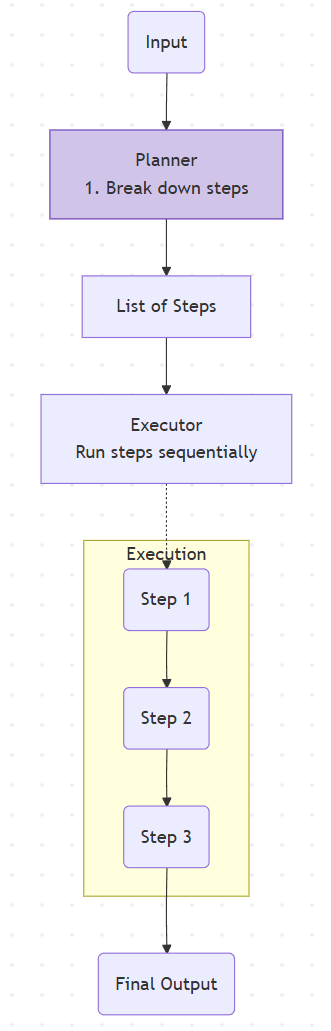


#### Orchestrator-Worker vs Planning

| 특성 | Orchestrator-Worker | Planning |
|------|---------------------|----------|
| **실행 방식** | 병렬 (독립적) | 순차적 (의존적) |
| **컨텍스트** | 각 Worker 독립 | 이전 결과 누적 |
| **적합한 경우** | 독립 섹션 분해 | 단계별 의존 작업 |

In [ ]:
# ========================================
# Planning Pattern with LangGraph
# ========================================

# 계획 구조
class Step(BaseModel):
    """실행 단계"""
    description: str = Field(description="단계 설명")

class Plan(BaseModel):
    """실행 계획"""
    steps: List[Step] = Field(description="실행 단계들")

plan_llm = llm.with_structured_output(Plan)

# State 정의
class PlanState(TypedDict):
    goal: str                                           # 목표
    steps: List[Step]                                   # 계획된 단계들
    current_step: int                                   # 현재 단계 인덱스
    results: Annotated[list, operator.add]              # 실행 결과들
    context: str                                        # 누적 컨텍스트
    synthesis: str                                      # 최종 종합

# Node 함수들
def planner(state: PlanState) -> dict:
    """계획 수립"""
    print(f"📋 Planner: 계획 수립 중...")
    print(f"   목표: {state['goal']}")

    result = plan_llm.invoke([
        SystemMessage(content="주어진 목표를 달성하기 위한 3-4단계 계획을 세우세요."),
        HumanMessage(content=f"목표: {state['goal']}")
    ])

    print(f"   → {len(result.steps)}단계 계획 수립:")
    for i, step in enumerate(result.steps, 1):
        print(f"      {i}. {step.description}")

    return {"steps": result.steps, "current_step": 0, "context": ""}

def executor(state: PlanState) -> dict:
    """현재 단계 실행"""
    idx = state["current_step"]
    step = state["steps"][idx]

    print(f"\n⚡ Executor: Step {idx + 1} 실행 중...")
    print(f"   작업: {step.description}")

    prompt = f"""작업: {step.description}

이전 컨텍스트: {state['context'] if state['context'] else '없음'}

이 단계를 수행하고 결과를 제시하세요."""

    msg = llm.invoke(prompt)
    result = msg.content

    new_context = state["context"] + f"\n\n[Step {idx + 1}] {step.description}\n결과: {result[:200]}..."

    return {
        "results": [{"step": idx + 1, "description": step.description, "result": result}],
        "current_step": idx + 1,
        "context": new_context
    }

def synthesize_plan(state: PlanState) -> dict:
    """결과 종합"""
    print(f"\n📊 Synthesizer: {len(state['results'])}개 결과 종합 중...")

    results_text = "\n".join([
        f"Step {r['step']}: {r['result'][:150]}..."
        for r in state['results']
    ])

    msg = llm.invoke(f"다음 단계별 결과들을 종합하여 최종 결과를 작성하세요:\n\n{results_text}")

    return {"synthesis": msg.content}

def should_continue_planning(state: PlanState) -> str:
    """모든 단계 완료 여부 확인"""
    if state["current_step"] >= len(state["steps"]):
        return "synthesize"
    return "execute"

# Graph 구성
plan_builder = StateGraph(PlanState)

plan_builder.add_node("planner", planner)
plan_builder.add_node("executor", executor)
plan_builder.add_node("synthesizer", synthesize_plan)

plan_builder.add_edge(START, "planner")
plan_builder.add_conditional_edges(
    "planner",
    should_continue_planning,
    {"execute": "executor", "synthesize": "synthesizer"}
)
plan_builder.add_conditional_edges(
    "executor",
    should_continue_planning,
    {"execute": "executor", "synthesize": "synthesizer"}
)
plan_builder.add_edge("synthesizer", END)

planning_workflow = plan_builder.compile()

print("✅ Planning Graph 생성 완료!")

In [ ]:
# Planning 실행 예시
result = planning_workflow.invoke({"goal": "Python으로 간단한 웹 크롤러 만들기"})
print(result["synthesis"])

---
## 9. 패턴 선택 가이드

### 요구사항별 추천 패턴

| 요구사항 | 추천 패턴 | LangGraph 핵심 |
|---------|----------|----------------|
| 고정된 단계 작업 | Prompt Chaining | `add_edge` 순차 연결 |
| 입력 유형별 처리 | Routing | `add_conditional_edges` |
| 빠른 처리, 독립 작업 | Parallelization | START에서 다중 엣지 |
| 복잡한 작업 동적 분해 | Orchestrator-Worker | `Send()` 동적 생성 |
| 추론과 행동 반복 | ReAct | Agent Loop + Tools |
| 품질 개선 필요 | Evaluator-Optimizer | 조건부 루프 |
| 외부 데이터/기능 필요 | Tool Use | tool 데코레이션 |
| 복잡한 목표 달성 | Planning | 순차 실행 + 컨텍스트 누적 |